In [1]:
import h5py

In [2]:
h5file = "/Users/epaudel/research_ua/icecube/upgrade/timing_calibration/data/degg_linaerity_hdf5/DEgg2021-0-001/pmt-SQ0424/linearity_20240223_00_SQ0424_0.32.hdf5"

In [3]:
with h5py.File(h5file, 'r') as f:
    # List all keys in the file
    print(list(f.keys()))
    
    # Access a dataset
    data = f['data'][:]
    parameters = f["parameters"]

['data', 'parameters']


In [5]:
print(data["waveform"])

[[1347. 1343. 1350. ... 1335. 1343. 1335.]
 [1349. 1344. 1343. ... 1335. 1333. 1333.]
 [1350. 1347. 1347. ... 1336. 1334. 1333.]
 ...
 [1344. 1352. 1344. ... 1343. 1345. 1334.]
 [1347. 1346. 1349. ... 1333. 1337. 1333.]
 [1344. 1345. 1349. ... 1340. 1336. 1334.]]


In [9]:
# extract all fields from structured ndarray `data`
datetime_timestamp = data['datetime_timestamp']
event_id = data['event_id']
pc_time = data['pc_time']
time_bins = data['time']      # shape (N, 128)
timestamp = data['timestamp']
waveform = data['waveform']   # shape (N, 128)

# quick summaries
print('datetime_timestamp shape:', datetime_timestamp.shape)
print('event_id shape:', event_id.shape)
print('pc_time shape:', pc_time.shape)
print('time shape:', time_bins.shape)
print('timestamp shape:', timestamp.shape)
print('waveform shape:', waveform.shape)

# example: inspect first record
i = 0
print('first record:')
print(' datetime_timestamp:', datetime_timestamp[i])
print(' event_id:', event_id[i])
print(' pc_time:', pc_time[i])
print(' timestamp:', timestamp[i])
print(' time bins (first 10):', time_bins[i][:10])
print(' waveform (first 10):', waveform[i][:10])

datetime_timestamp shape: (5001,)
event_id shape: (5001,)
pc_time shape: (5001,)
time shape: (5001, 128)
timestamp shape: (5001,)
waveform shape: (5001, 128)
first record:
 datetime_timestamp: 1708652477.905852
 event_id: 0
 pc_time: -1.6962213e+09
 timestamp: 54505195275492
 time bins (first 10): [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
 waveform (first 10): [1347. 1343. 1350. 1350. 1345. 1343. 1349. 1346. 1344. 1348.]


In [8]:
print(data["time"])

[[  0.   1.   2. ... 125. 126. 127.]
 [  0.   1.   2. ... 125. 126. 127.]
 [  0.   1.   2. ... 125. 126. 127.]
 ...
 [  0.   1.   2. ... 125. 126. 127.]
 [  0.   1.   2. ... 125. 126. 127.]
 [  0.   1.   2. ... 125. 126. 127.]]


In [ ]:
with h5py.File(h5file, "r") as f:
    params = f["parameters"]
    
    print("Parameter keys:", list(params.keys()))
    print("Parameter attrs:", dict(params.attrs))
    
    # Read all datasets in the group into a dictionary
    parameters_data = {key: params[key][()] for key in params.keys()}
    print(parameters_data)

Parameter keys: ['keys', 'values']
Parameter attrs: {'CLASS': np.bytes_(b'GROUP'), 'TITLE': np.bytes_(b'Parameters used for this measurement'), 'VERSION': np.bytes_(b'1.0')}
{'keys': array([b'DEggSerialNumber', b'UpperGlassSerialNumber',
       b'LowerGlassSerialNumber', ..., b'OnlineMon_30.HV0Result',
       b'OnlineMon_30.HV1Result', b'OnlineMon_30.RemoteFolder'],
      shape=(1472,), dtype='|S60'), 'values': array([b'DEgg2021-0-001', b'2021-0-001U', b'2021-0-001L', ..., b'1', b'1',
       b'/disk20/fat/data/fat_callibration/online_monitoring/20240223_01'],
      shape=(1472,), dtype='|S217')}


In [23]:
print(parameters)

<Closed HDF5 group>


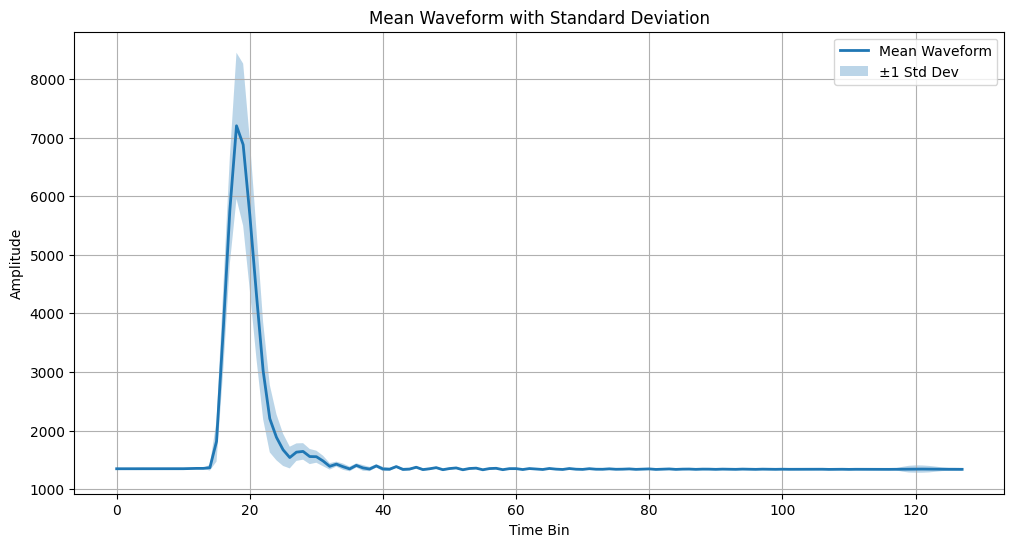

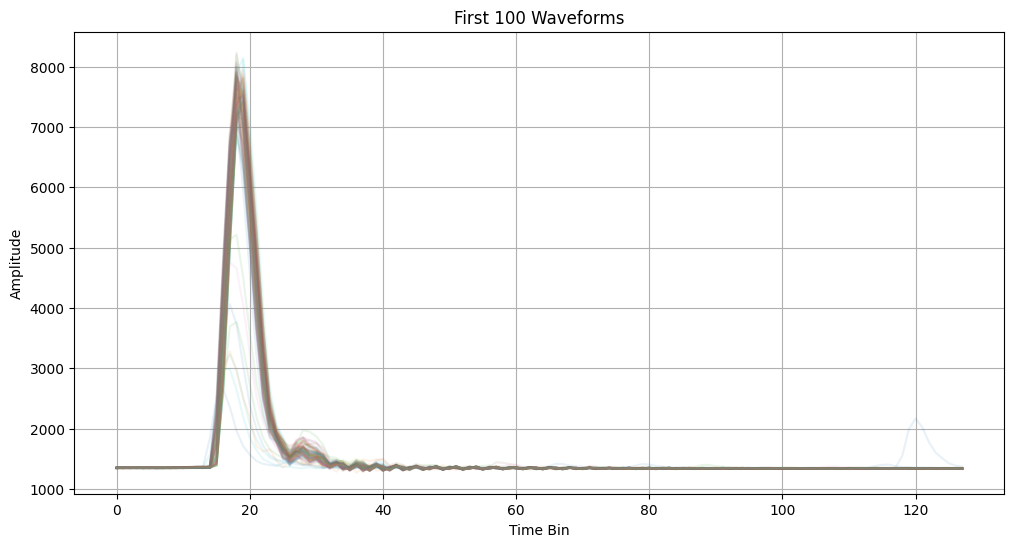

In [12]:
import numpy as np

import matplotlib.pyplot as plt

# Extract waveforms and calculate statistics
waveforms = data['waveform']
mean_waveform = np.mean(waveforms, axis=0)
std_waveform = np.std(waveforms, axis=0)
time_bins = data['time'][0]

# Plot mean waveform with standard deviation
plt.figure(figsize=(12, 6))
plt.plot(time_bins, mean_waveform, label='Mean Waveform', linewidth=2)
plt.fill_between(time_bins, mean_waveform - std_waveform, mean_waveform + std_waveform, alpha=0.3, label='±1 Std Dev')
plt.xlabel('Time Bin')
plt.ylabel('Amplitude')
plt.title('Mean Waveform with Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()

# Plot individual waveforms
plt.figure(figsize=(12, 6))
for i in range(min(100, len(waveforms))):
    plt.plot(time_bins, waveforms[i], alpha=0.1)
plt.xlabel('Time Bin')
plt.ylabel('Amplitude')
plt.title('First 100 Waveforms')
plt.grid(True)
plt.show()

In [ ]:
data